# 模块十二：计算机视觉
## 12.1 图像分割

> **课时安排**：约2课时  
> **学习目标**：
> - 理解图像分割的基本概念和三种主要类型
> - 掌握语义分割、实例分割、全景分割的区别
> - 了解U-Net架构的编码器-解码器结构与跳跃连接
> - 学会使用OpenCV进行基础图像处理（颜色空间转换、阈值分割、边缘检测、轮廓检测）
> - 能够使用Python + OpenCV完成简单图像分割任务

---

## 一、图像分割概述

### 1.1 什么是图像分割？

**图像分割**（Image Segmentation）是指将数字图像划分为多个**像素组/区域**的过程，使得：
- 同一区域内的像素具有**相似的特性**（颜色、纹理、亮度等）
- 不同区域之间的像素具有**明显的差异**

图像分割是计算机视觉中的核心任务之一，它是从"图像分类"到"像素级理解"的关键一步。

### 1.2 图像分割的应用场景

| 应用领域 | 具体场景 |
|---------|---------|
| **医学影像** | 肿瘤检测、器官分割、细胞计数 |
| **自动驾驶** | 可行驶区域检测、车道线分割 |
| **遥感图像** | 土地覆盖分类、建筑提取 |
| **工业检测** | 缺陷检测、零件分割 |
| **图像编辑** | 背景替换、人像抠图 |
| **机器人** | 抓取目标分割、障碍物识别 |

---

## 二、图像分割的三种类型

### 2.1 语义分割（Semantic Segmentation）

**语义分割**对图像中的**每个像素**进行类别分类，但**不区分同一类别的不同实例**。

- 每个像素分配一个类别标签
- 同一类别的不同物体被合并
- 输出：与输入同尺寸的**类别标签图**

**代表模型**：
- FCN（Fully Convolutional Networks, 2015）
- DeepLab系列（v1, v2, v3+）
- PSPNet

### 2.2 实例分割（Instance Segmentation）

**实例分割**不仅要识别每个像素的类别，还要**区分同一类别的不同实例**。

- 在语义分割的基础上增加实例ID
- 每个"物体"都有独立的分割掩码（mask）
- 输出：每个实例的**独立二值掩码** + 类别标签 + 置信度

**代表模型**：
- Mask R-CNN（2017）
- YOLACT
- SOLO / SOLOv2

### 2.3 全景分割（Panoptic Segmentation）

**全景分割**是语义分割和实例分割的**统一框架**：

$$\text{全景分割} = \text{语义分割（Stuff类别）} + \text{实例分割（Thing类别）}$$

- **"Stuff"类别**：无固定形状的区域（天空、道路、草地、墙壁等）
- **"Thing"类别**：有固定形状的实例（人、车、动物等）

**代表模型**：
- Panoptic FPN（2019）
- Panoptic-DeepLab

### 2.4 三种分割对比

```
原图:  [一只猫坐在草地上的沙发上]

语义分割:  全部猫像素 → "猫"，全部草地像素 → "草"，全部沙发像素 → "沙发"

实例分割:  猫#1 → 猫掩码1（如果有第二只猫，则是猫掩码2）

全景分割:  草地 → "草"(Stuff)，天空 → "天空"(Stuff)，
           猫#1 → "猫"(Thing, 实例1)


### 2.5 语义分割的里程碑：FCN

**FCN（Fully Convolutional Networks）** 是语义分割的开创性工作（Long et al., 2015）。

**核心思想**：
1. 将分类网络（VGG/ResNet）中的**全连接层替换为卷积层**
2. 使用**反卷积（转置卷积）**进行上采样，恢复空间分辨率
3. 输出与输入**同尺寸**的像素级分类图

**三种变体**：

| 变体 | 策略 | 精度 | 速度 |
|------|------|------|------|
| FCN-32s | 直接上采样32倍 | 低 | 快 |
| FCN-16s | 结合pool4特征上采样16倍 | 中 | 中 |
| FCN-8s | 结合pool3+pool4特征上采样8倍 | 高 | 慢 |

**FCN的跳跃连接思想**：

$$\hat{y} = \text{upsample}(\text{conv}(\text{pool5})) + \text{conv}(\text{pool4}) + \text{conv}(\text{pool3})$$

这种多尺度特征融合的思想后来被U-Net等架构继承和发扬。

---

## 三、Mask R-CNN概述

**Mask R-CNN**（He et al., 2017）是实例分割的经典模型。

**架构**：
```
输入图像 → Backbone（ResNet-FPN）→ RPN → RoI Align → 
    ├── 分类分支（是什么类别）
    ├── 回归分支（边界框精调）
    └── 掩码分支（每个RoI生成28×28二值掩码）
```

**关键创新**：
1. **RoI Align**：用双线性插值替代RoI Pooling，解决特征不对齐问题
2. **解耦任务**：分类和掩码预测解耦，每个类别独立预测掩码
3. **多任务损失**：
$$\mathcal{L} = \mathcal{L}_{cls} + \mathcal{L}_{box} + \mathcal{L}_{mask}$$

---

## 四、U-Net架构

### 4.1 编码器-解码器结构

**U-Net**（Ronneberger et al., 2015）最初为医学图像分割设计，因其简洁高效而被广泛应用。

**核心结构**：像一个"U"字形
- **编码器（Encoder）**：逐层下采样，提取高层语义特征
- **瓶颈层（Bottleneck）**：最深层特征
- **解码器（Decoder）**：逐层上采样，恢复空间分辨率

### 4.2 跳跃连接（Skip Connection）

U-Net的关键设计是**跳跃连接**：

```
编码器特征（高分辨率 + 低语义）  ──→ 拼接（Concatenate）──→ 解码器
                                          ↑
                                        上采样
                                          ↑
解码器特征（低分辨率 + 高语义） ─────────────┘
```

**跳跃连接的作用**：
1. **保留空间细节**：编码器浅层特征有丰富的位置信息
2. **恢复分辨率**：解码器需要精细的空间信息来生成分割边界
3. **缓解信息丢失**：弥补下采样过程中丢失的细节

**U-Net的数学表达**：

$$x^{l}_{dec} = \text{Conv}(\text{Concat}(\text{Up}(x^{l+1}_{dec}),\; x^{l}_{enc}))$$

其中 $x^{l}_{enc}$ 是编码器第 $l$ 层的特征，$x^{l+1}_{dec}$ 是解码器上一层上采样后的特征，$\text{Up}$ 是上采样操作，$\text{Concat}$ 是通道维拼接。

### 4.3 U-Net的PyTorch实现（简化版）

下面我们用PyTorch实现一个简化的U-Net：

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """U-Net中的双卷积块"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    """简化版U-Net"""
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()
        # 编码器（下采样）
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        
        self.pool = nn.MaxPool2d(2)
        
        # 瓶颈层
        self.bottleneck = DoubleConv(512, 1024)
        
        # 解码器（上采样）
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        
        # 输出层
        self.out = nn.Conv2d(64, num_classes, kernel_size=1)
    
    def forward(self, x):
        # 编码器
        e1 = self.enc1(x)       # [B, 64, H, W]
        e2 = self.enc2(self.pool(e1))   # [B, 128, H/2, W/2]
        e3 = self.enc3(self.pool(e2))   # [B, 256, H/4, W/4]
        e4 = self.enc4(self.pool(e3))   # [B, 512, H/8, W/8]
        
        # 瓶颈
        b = self.bottleneck(self.pool(e4))  # [B, 1024, H/16, W/16]
        
        # 解码器 + 跳跃连接
        d4 = self.upconv4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))  # 拼接: 512+512=1024
        
        d3 = self.upconv3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = self.upconv2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = self.upconv1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        
        return self.out(d1)  # [B, num_classes, H, W]

# 创建模型并查看结构
model = UNet(in_channels=3, num_classes=2)
x = torch.randn(1, 3, 256, 256)
output = model(x)
print(f"输入尺寸: {x.shape}")
print(f"输出尺寸: {output.shape}")
print(f"模型参数量: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nU-Net架构成功！编码器提取特征，解码器通过跳跃连接恢复分辨率。")


输入尺寸: torch.Size([1, 3, 256, 256])
输出尺寸: torch.Size([1, 2, 256, 256])
模型参数量: 31,043,586

U-Net架构成功！编码器提取特征，解码器通过跳跃连接恢复分辨率。


---

## 五、OpenCV图像处理基础

### 5.1 安装和导入

```bash
pip install opencv-python numpy matplotlib
```

OpenCV是计算机视觉领域最经典的开源库，提供了丰富的图像处理函数。

### 5.2 图像读取、显示、保存

在Jupyter中，我们使用matplotlib来显示OpenCV读取的图像：

图像尺寸 (高度, 宽度, 通道数): (300, 400, 3)
图像数据类型: uint8
像素值范围: [0, 255]


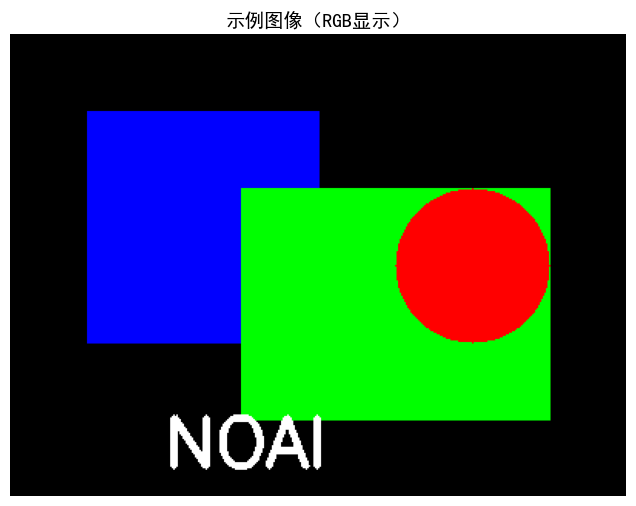

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 设置Matplotlib显示中文字体（防止中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']               # 显示中文
plt.rcParams['axes.unicode_minus'] = False                 # 正常显示负号

# 创建一个示例图像（如果环境中有实际图像可替换）
# 这里生成一个简单的测试图像
img = np.zeros((300, 400, 3), dtype=np.uint8)

# 画一些图形作为示例
cv2.rectangle(img, (50, 50), (200, 200), (255, 0, 0), -1)   # 蓝色矩形
cv2.rectangle(img, (150, 100), (350, 250), (0, 255, 0), -1)   # 绿色矩形
cv2.circle(img, (300, 150), 50, (0, 0, 255), -1)              # 红色圆形
cv2.putText(img, 'NOAI', (100, 280), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 3)

print(f"图像尺寸 (高度, 宽度, 通道数): {img.shape}")
print(f"图像数据类型: {img.dtype}")
print(f"像素值范围: [{img.min()}, {img.max()}]")

# OpenCV读取图像时默认是BGR格式
# 使用matplotlib显示时需要转为RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title('示例图像（RGB显示）', fontsize=14)
plt.axis('off')
plt.show()


### 5.3 颜色空间转换

OpenCV支持多种颜色空间，常用的转换包括：

| 转换 | 函数 | 应用场景 |
|------|------|---------|
| BGR → RGB | `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` | matplotlib显示 |
| BGR → Gray | `cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)` | 灰度处理、边缘检测 |
| BGR → HSV | `cv2.cvtColor(img, cv2.COLOR_BGR2HSV)` | 颜色过滤、目标跟踪 |

**HSV颜色空间**特别适合基于颜色的分割：
- **H（Hue）**：色调，0°-360°（OpenCV中为0-180）
- **S（Saturation）**：饱和度，0-255
- **V（Value）**：明度，0-255

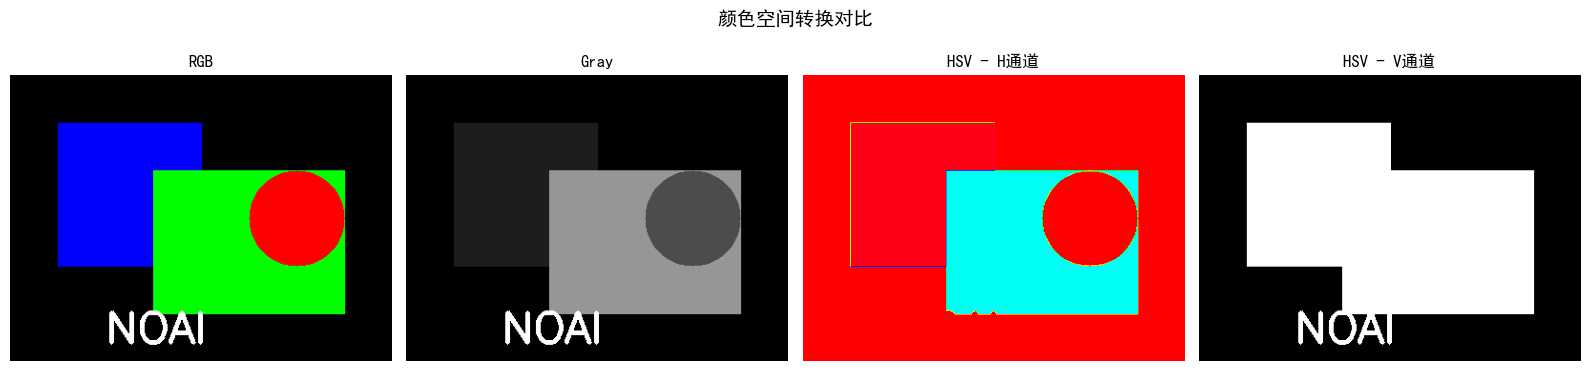

原图形状: (300, 400, 3)
灰度图形状: (300, 400)
HSV图形状: (300, 400, 3)


In [17]:
# 颜色空间转换演示
img_bgr = img  # OpenCV默认BGR
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_rgb)
axes[0].set_title('RGB', fontsize=12)
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('Gray', fontsize=12)
axes[1].axis('off')

axes[2].imshow(img_hsv[:,:,0], cmap='hsv')
axes[2].set_title('HSV - H通道', fontsize=12)
axes[2].axis('off')

axes[3].imshow(img_hsv[:,:,2], cmap='gray')
axes[3].set_title('HSV - V通道', fontsize=12)
axes[3].axis('off')

plt.suptitle('颜色空间转换对比', fontsize=14)
plt.tight_layout()
plt.show()

print(f"原图形状: {img_rgb.shape}")
print(f"灰度图形状: {img_gray.shape}")
print(f"HSV图形状: {img_hsv.shape}")


### 5.4 阈值分割

**阈值分割**是最简单的分割方法：将像素值与阈值比较，分为前景和背景。

**Otsu阈值法**（大津法）是一种自适应阈值选择方法：

- 自动寻找使**类间方差最大**的阈值 $T^*$
- 无需手动设置阈值
- 数学表达：

$$T^* = \arg\max_{T} \sigma_B^2(T) = \arg\max_T \omega_1(T)\omega_2(T)[\mu_1(T) - \mu_2(T)]^2$$

其中 $\omega_1, \omega_2$ 是两类像素的比例，$\mu_1, \mu_2$ 是两类像素的均值。

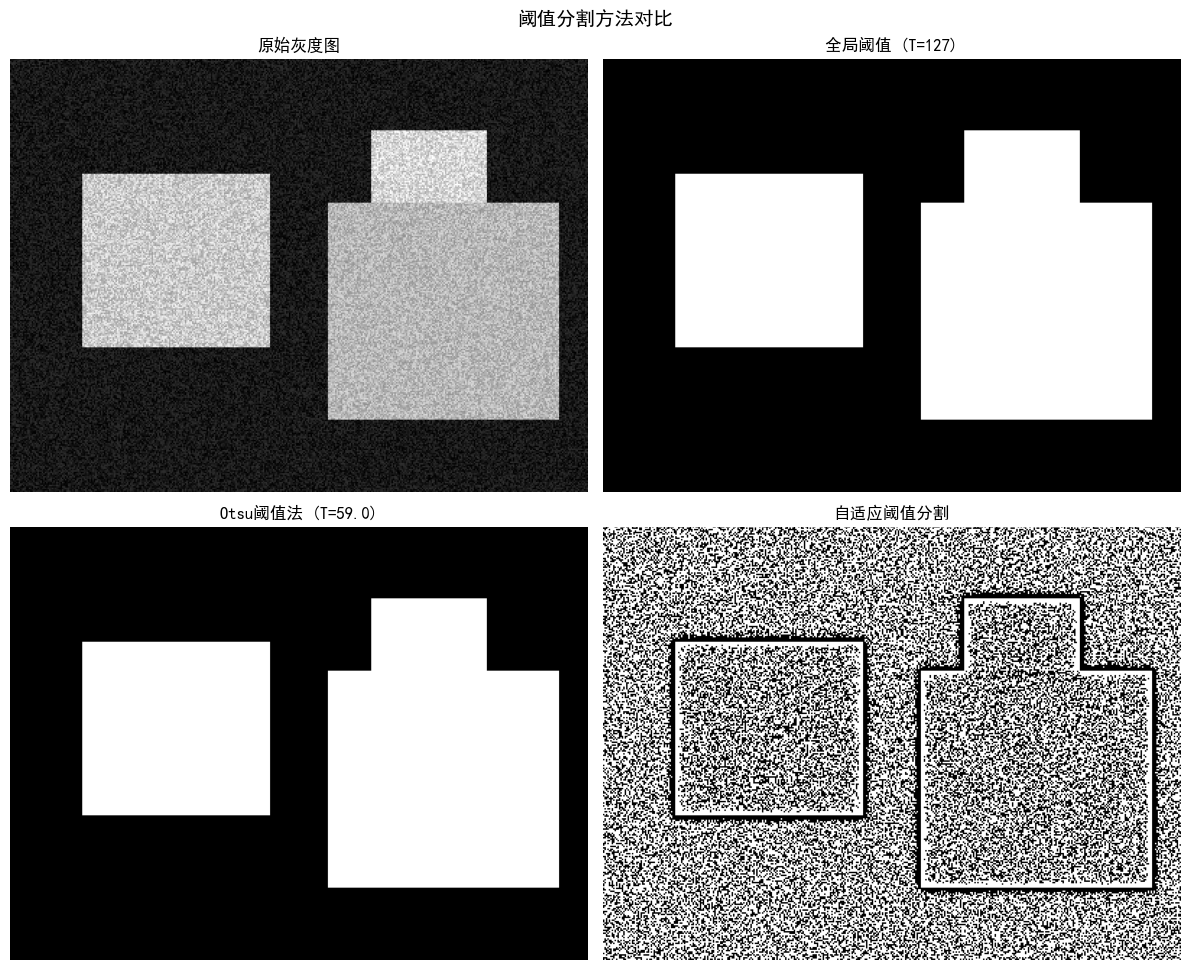

Otsu自动计算的最优阈值: 59.0

可以看到Otsu方法自动找到了合适的阈值，将前景和背景很好地分离开来。


In [18]:
# 创建更适合演示阈值分割的图像
# 生成带有前景和背景的灰度图像
np.random.seed(42)
img_threshold = np.zeros((300, 400), dtype=np.uint8)

# 背景
img_threshold[:,:] = np.random.randint(20, 60, (300, 400)).astype(np.uint8)

# 前景物体（较亮区域）
img_threshold[80:200, 50:180] = np.random.randint(150, 220, (120, 130)).astype(np.uint8)
img_threshold[100:250, 220:380] = np.random.randint(140, 200, (150, 160)).astype(np.uint8)
img_threshold[50:100, 250:330] = np.random.randint(160, 230, (50, 80)).astype(np.uint8)

# --- 全局阈值分割 ---
ret1, thresh_binary = cv2.threshold(img_threshold, 127, 255, cv2.THRESH_BINARY)

# --- Otsu阈值法 ---
ret2, thresh_otsu = cv2.threshold(img_threshold, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# --- 自适应阈值分割 ---
thresh_adaptive = cv2.adaptiveThreshold(
    img_threshold, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 15, 5
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].imshow(img_threshold, cmap='gray')
axes[0,0].set_title(f'原始灰度图', fontsize=12)
axes[0,0].axis('off')

axes[0,1].imshow(thresh_binary, cmap='gray')
axes[0,1].set_title(f'全局阈值 (T=127)', fontsize=12)
axes[0,1].axis('off')

axes[1,0].imshow(thresh_otsu, cmap='gray')
axes[1,0].set_title(f'Otsu阈值法 (T={ret2})', fontsize=12)
axes[1,0].axis('off')

axes[1,1].imshow(thresh_adaptive, cmap='gray')
axes[1,1].set_title('自适应阈值分割', fontsize=12)
axes[1,1].axis('off')

plt.suptitle('阈值分割方法对比', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Otsu自动计算的最优阈值: {ret2}")
print(f"\n可以看到Otsu方法自动找到了合适的阈值，将前景和背景很好地分离开来。")


### 5.5 边缘检测（Canny）

**Canny边缘检测**是最流行的边缘检测算法，包含4个步骤：

1. **高斯滤波**：平滑图像，减少噪声
2. **计算梯度**：使用Sobel算子计算 $x$ 和 $y$ 方向的梯度
3. **非极大值抑制**：细化边缘（保留梯度方向上的最大值）
4. **双阈值检测**：用高低两个阈值判断边缘（强边缘/弱边缘/非边缘）

**Sobel梯度计算**：

$$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} * I, \quad G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix} * I$$

$$G = \sqrt{G_x^2 + G_y^2}, \quad \theta = \arctan\frac{G_y}{G_x}$$

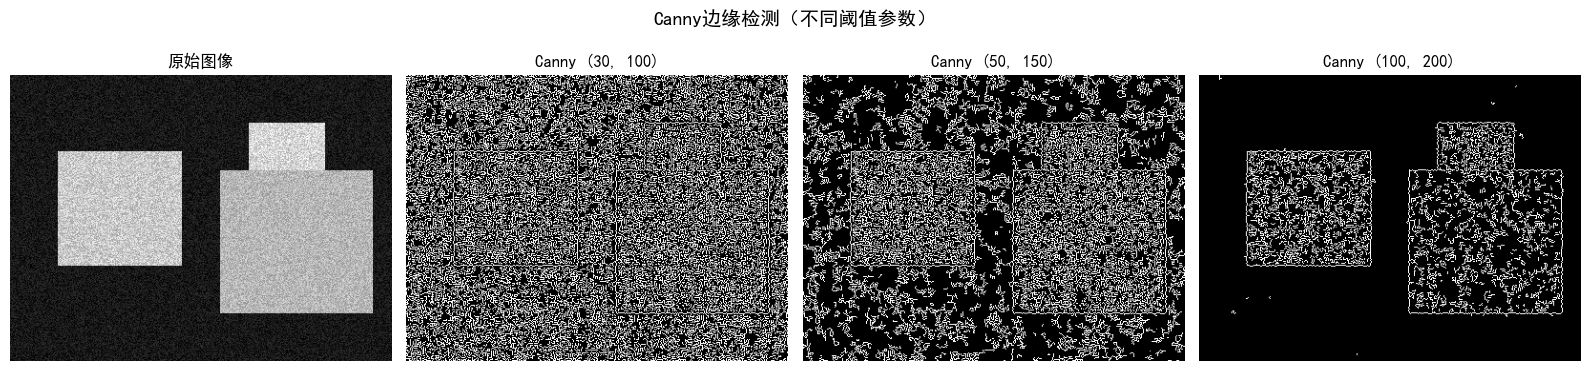

阈值越低，检测到的边缘越多（但噪声也越多）
阈值越高，检测到的边缘越少（但更干净）
实际应用中需要根据场景调整这两个阈值参数。


In [19]:
# Canny边缘检测
edges_low = cv2.Canny(img_threshold, 30, 100)    # 低阈值
edges_mid = cv2.Canny(img_threshold, 50, 150)    # 中阈值
edges_high = cv2.Canny(img_threshold, 100, 200)  # 高阈值

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_threshold, cmap='gray')
axes[0].set_title('原始图像', fontsize=12)
axes[0].axis('off')

axes[1].imshow(edges_low, cmap='gray')
axes[1].set_title('Canny (30, 100)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(edges_mid, cmap='gray')
axes[2].set_title('Canny (50, 150)', fontsize=12)
axes[2].axis('off')

axes[3].imshow(edges_high, cmap='gray')
axes[3].set_title('Canny (100, 200)', fontsize=12)
axes[3].axis('off')

plt.suptitle('Canny边缘检测（不同阈值参数）', fontsize=14)
plt.tight_layout()
plt.show()

print("阈值越低，检测到的边缘越多（但噪声也越多）")
print("阈值越高，检测到的边缘越少（但更干净）")
print("实际应用中需要根据场景调整这两个阈值参数。")


### 5.6 轮廓检测

**轮廓检测**用于提取图像中物体的边界轮廓。

常用操作：
- `cv2.findContours()`：查找轮廓
- `cv2.drawContours()`：绘制轮廓
- `cv2.contourArea()`：计算轮廓面积
- `cv2.boundingRect()`：获取外接矩形

检测到 2 个轮廓
  轮廓1: 面积=15351 px², 外接矩形: 位置(50,80), 尺寸130×120
  轮廓2: 面积=27642 px², 外接矩形: 位置(220,50), 尺寸160×200


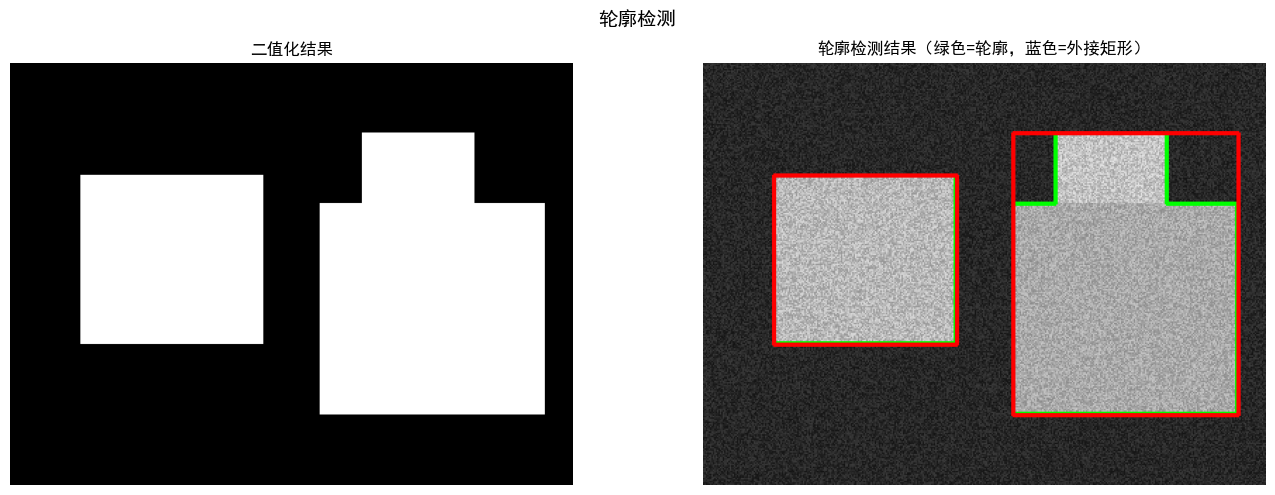

In [20]:
# 轮廓检测演示
contours, hierarchy = cv2.findContours(
    thresh_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

print(f"检测到 {len(contours)} 个轮廓")

# 在原图上绘制轮廓
img_contours = cv2.cvtColor(img_threshold, cv2.COLOR_GRAY2BGR)
img_contours = cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB)

for i, contour in enumerate(contours):
    area = cv2.contourArea(contour)
    if area > 500:  # 过滤小轮廓
        # 绘制轮廓
        cv2.drawContours(img_contours, [contour], -1, (0, 255, 0), 2)
        
        # 绘制外接矩形
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(img_contours, (x, y), (x+w, y+h), (255, 0, 0), 2)
        
        print(f"  轮廓{i+1}: 面积={area:.0f} px², "
              f"外接矩形: 位置({x},{y}), 尺寸{w}×{h}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(thresh_otsu, cmap='gray')
axes[0].set_title('二值化结果', fontsize=12)
axes[0].axis('off')

axes[1].imshow(img_contours)
axes[1].set_title('轮廓检测结果（绿色=轮廓，蓝色=外接矩形）', fontsize=12)
axes[1].axis('off')

plt.suptitle('轮廓检测', fontsize=14)
plt.tight_layout()
plt.show()


### 5.7 基于颜色的分割（HSV）

利用HSV颜色空间可以方便地提取特定颜色的区域：

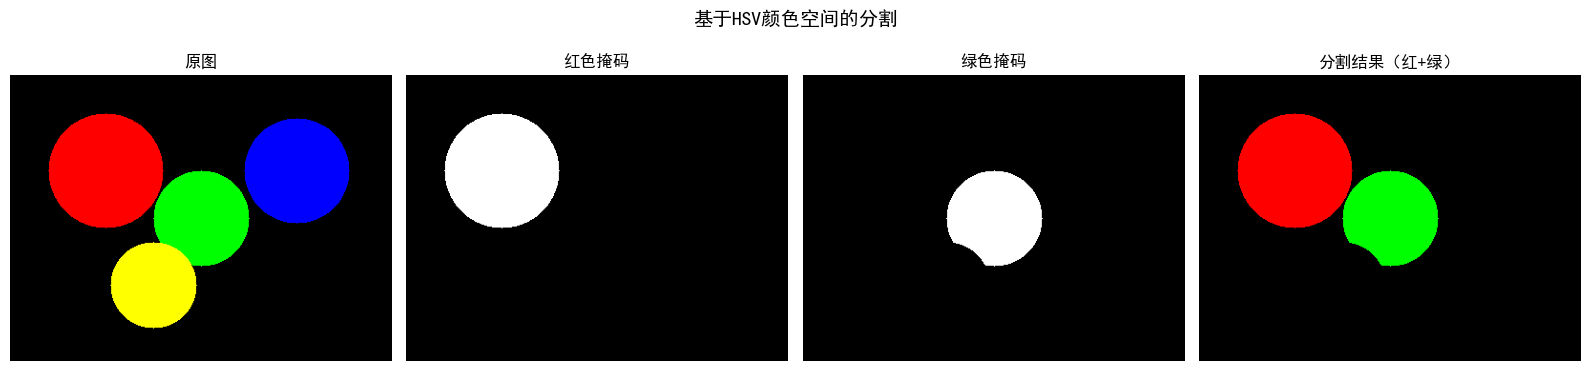

HSV颜色空间中，H通道对颜色最敏感，适合用于颜色分割。
实际应用中可根据需要调整H/S/V的上下界。


In [21]:
# 基于HSV颜色空间的分割
# 创建一个包含不同颜色物体的图像
img_color = np.zeros((300, 400, 3), dtype=np.uint8)

# 红色区域
cv2.circle(img_color, (100, 100), 60, (0, 0, 255), -1)
# 绿色区域
cv2.circle(img_color, (200, 150), 50, (0, 255, 0), -1)
# 蓝色区域
cv2.circle(img_color, (300, 100), 55, (255, 0, 0), -1)
# 黄色区域
cv2.circle(img_color, (150, 220), 45, (0, 255, 255), -1)

# 转换到HSV空间
img_hsv_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2HSV)

# 提取红色区域（红色在HSV中分布在H=0附近和H=170-180附近）
# OpenCV中H范围为0-180（对应0-360度）
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 100, 100])
upper_red2 = np.array([180, 255, 255])

mask_red1 = cv2.inRange(img_hsv_color, lower_red1, upper_red1)
mask_red2 = cv2.inRange(img_hsv_color, lower_red2, upper_red2)
mask_red = cv2.bitwise_or(mask_red1, mask_red2)

# 提取绿色区域
lower_green = np.array([35, 100, 100])
upper_green = np.array([85, 255, 255])
mask_green = cv2.inRange(img_hsv_color, lower_green, upper_green)

# 组合所有掩码
mask_all = cv2.bitwise_or(mask_red, mask_green)

# 应用掩码
result = cv2.bitwise_and(img_color, img_color, mask=mask_all)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_color_rgb)
axes[0].set_title('原图', fontsize=12)
axes[0].axis('off')

axes[1].imshow(mask_red, cmap='gray')
axes[1].set_title('红色掩码', fontsize=12)
axes[1].axis('off')

axes[2].imshow(mask_green, cmap='gray')
axes[2].set_title('绿色掩码', fontsize=12)
axes[2].axis('off')

axes[3].imshow(result_rgb)
axes[3].set_title('分割结果（红+绿）', fontsize=12)
axes[3].axis('off')

plt.suptitle('基于HSV颜色空间的分割', fontsize=14)
plt.tight_layout()
plt.show()

print("HSV颜色空间中，H通道对颜色最敏感，适合用于颜色分割。")
print("实际应用中可根据需要调整H/S/V的上下界。")


---

## 六、综合示例：分水岭算法

**分水岭算法**（Watershed）是一种基于拓扑理论的图像分割方法。

**原理**：
1. 将灰度图像想象为地形（亮度=海拔）
2. 从局部最小值开始"注水"
3. 不同区域的水汇聚时形成"分水岭"（分割边界）

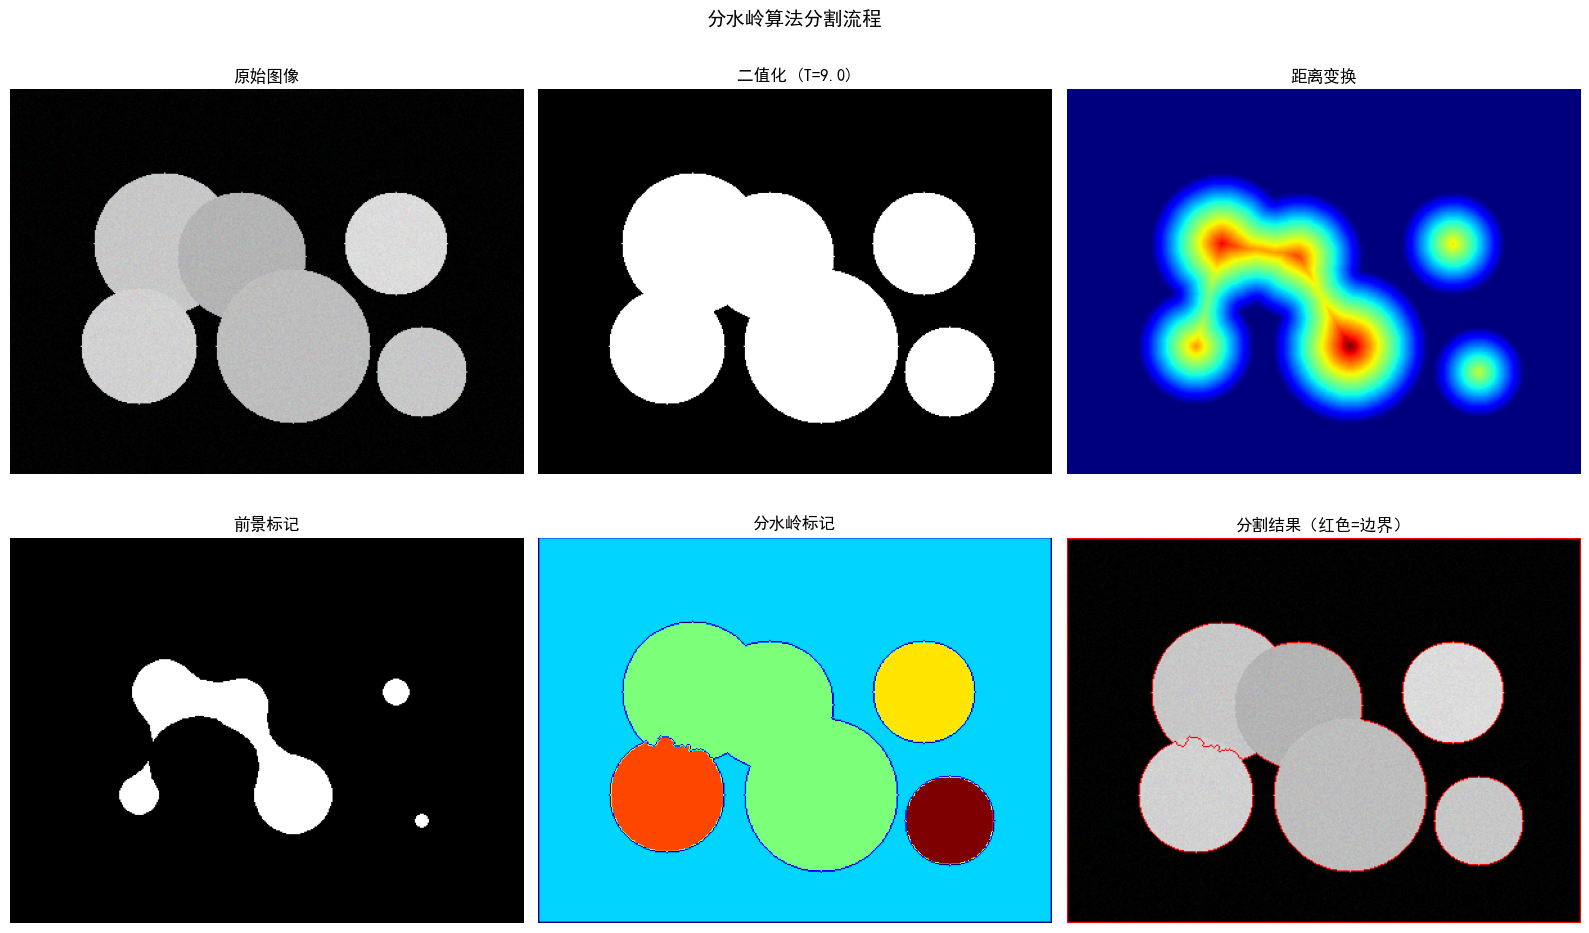

分水岭算法分割出 4 个物体


In [22]:
# 分水岭分割示例
# 创建带有重叠物体的图像
img_watershed = np.zeros((300, 400, 3), dtype=np.uint8)

# 绘制一些重叠的圆（模拟细胞）
cv2.circle(img_watershed, (120, 120), 55, (200, 200, 200), -1)
cv2.circle(img_watershed, (180, 130), 50, (180, 180, 180), -1)
cv2.circle(img_watershed, (100, 200), 45, (210, 210, 210), -1)
cv2.circle(img_watershed, (220, 200), 60, (190, 190, 190), -1)
cv2.circle(img_watershed, (300, 120), 40, (220, 220, 220), -1)
cv2.circle(img_watershed, (320, 220), 35, (200, 200, 200), -1)

# 添加噪声
noise = np.random.randint(-10, 10, img_watershed.shape, dtype=np.int16)
img_watershed = np.clip(img_watershed.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# 转为灰度图
gray = cv2.cvtColor(img_watershed, cv2.COLOR_BGR2GRAY)

# Otsu二值化
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 形态学开运算去除噪声
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# 确定背景区域
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# 距离变换确定前景
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret2, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)

# 未知区域
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# 标记分水岭区域
ret3, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1  # 加1，确保背景不是0
markers[unknown == 255] = 0

# 应用分水岭
img_watershed_rgb = cv2.cvtColor(img_watershed, cv2.COLOR_BGR2RGB)
markers_rgb = cv2.watershed(img_watershed, markers)
img_watershed_rgb[markers_rgb == -1] = [255, 0, 0]  # 边界标记为红色

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0,0].imshow(cv2.cvtColor(img_watershed, cv2.COLOR_BGR2RGB))
axes[0,0].set_title('原始图像', fontsize=12)
axes[0,0].axis('off')

axes[0,1].imshow(thresh, cmap='gray')
axes[0,1].set_title(f'二值化 (T={ret})', fontsize=12)
axes[0,1].axis('off')

axes[0,2].imshow(dist_transform, cmap='jet')
axes[0,2].set_title('距离变换', fontsize=12)
axes[0,2].axis('off')

axes[1,0].imshow(sure_fg, cmap='gray')
axes[1,0].set_title('前景标记', fontsize=12)
axes[1,0].axis('off')

axes[1,1].imshow(markers_rgb, cmap='jet')
axes[1,1].set_title('分水岭标记', fontsize=12)
axes[1,1].axis('off')

axes[1,2].imshow(img_watershed_rgb)
axes[1,2].set_title('分割结果（红色=边界）', fontsize=12)
axes[1,2].axis('off')

plt.suptitle('分水岭算法分割流程', fontsize=14)
plt.tight_layout()
plt.show()

num_objects = markers_rgb.max() - 1  # 减去背景标记
print(f"分水岭算法分割出 {num_objects} 个物体")


---

## 七、图像分割方法总结

### 7.1 传统方法 vs 深度学习方法

| 方法 | 代表算法 | 优点 | 缺点 |
|------|---------|------|------|
| **阈值分割** | Otsu、自适应阈值 | 简单快速 | 只适合双峰直方图 |
| **边缘检测** | Canny、Sobel | 计算高效 | 不连续边缘、噪声敏感 |
| **区域生长** | Flood Fill | 思路直观 | 需要种子点 |
| **分水岭** | Watershed | 处理重叠物体 | 容易过分割 |
| **聚类** | K-Means、Mean Shift | 无监督 | 需要预设类别数 |
| **语义分割** | FCN、DeepLab | 像素级分类 | 不区分实例 |
| **实例分割** | Mask R-CNN | 区分实例 | 计算量大 |
| **全景分割** | Panoptic FPN | 统一框架 | 复杂度高 |

### 7.2 关键概念回顾

$$\text{图像分割层次}$$

```
图像分类 → "这是一只猫"
    ↓
目标检测 → "这是一只猫，在位置(x,y,w,h)"
    ↓
语义分割 → "这些像素属于猫"
    ↓
实例分割 → "这组像素是猫#1，那组像素是猫#2"
    ↓
全景分割 → "天空是Stuff，猫#1和猫#2是Thing"
```

---

## 八、练习题

### 练习1：基础概念
请简述以下概念的区别：
1. 语义分割 vs 实例分割 vs 全景分割
2. FCN和U-Net都使用了跳跃连接，它们的作用是什么？
3. 为什么U-Net在医学图像分割中表现特别好？

### 练习2：OpenCV实践
使用OpenCV完成以下任务（代码框架如下）：

```python
import cv2
import numpy as np
import matplotlib.pyplot as plt

# TODO: 读取一张图片（或创建示例图片）
# TODO: 转换为HSV空间
# TODO: 尝试提取特定颜色的区域
# TODO: 使用Canny进行边缘检测
# TODO: 找到轮廓并计算每个轮廓的面积和周长
```

### 练习3：U-Net分析
1. 如果将U-Net的编码器从4层扩展到5层（增加一次下采样），模型参数量会如何变化？
2. 如果去掉跳跃连接，只用编码器-解码器结构，分割效果会如何？为什么？

### 练习4：思考题
在实际医学影像分割任务中，如果训练样本很少（比如只有50张标注图像），你会如何设计方案？
- 提示：思考数据增强、迁移学习、U-Net的小数据优势等。

---

> **本节小结**：
> - 图像分割分为语义分割、实例分割和全景分割三大类
> - FCN开创了端到端语义分割，U-Net通过跳跃连接实现了精细分割
> - Mask R-CNN是实例分割的经典模型
> - OpenCV提供了丰富的传统图像处理工具：颜色空间转换、阈值分割、边缘检测、轮廓检测
> - 传统方法简单高效但能力有限，深度学习方法精度高但需要大量数据和计算资源
>
> **下一节**：12.2 目标检测 — 学习如何同时解决"是什么"和"在哪里"的问题
